# Práctica 4: Isomorfismo de Gráficas — Clase **GI**
### Complejidad Computacional · Facultad de Ciencias, UNAM

---

## 1. Contexto teórico

> **GI (Graph Isomorphism):** Dadas dos gráficas $G_1 = (V_1, E_1)$ y $G_2 = (V_2, E_2)$
> (representadas por matrices de adyacencia), ¿existe una biyección
> $\varphi: V_1 \to V_2$ tal que $(u, v) \in E_1 \iff (\varphi(u), \varphi(v)) \in E_2$?

Llamamos a $\varphi$ un **isomorfismo** entre $G_1$ y $G_2$.

**Posición en la jerarquía de complejidad:**
- GI $\in$ **NP** (el isomorfismo es un certificado verificable en tiempo polinomial).
- GI $\in$ **co-AM** (⊆ co-NP de manera probabilística).
- GI es **GI-completo** (muchos problemas de isomorfismo se reducen a GI).
- **No se sabe** si GI está en P o si es NP-completo.
- **Babai (2015):** algoritmo quasi-cuasi-polinomial $n^{\text{poly}(\log n)}$ —
  el mayor avance en décadas (aunque con una corrección posterior en 2017).

**En esta práctica implementarás:**
1. Fuerza bruta: probar todas las biyecciones posibles — $O(n!)$.
2. El algoritmo de Weisfeiler-Leman (1-WL): condición **necesaria** pero no
   suficiente — $O(n^2 \log n)$.

---

## 2. Objetivo

1. Implementar el verificador de isomorfismo por fuerza bruta.
2. Implementar la prueba de coloreo de Weisfeiler-Leman.
3. Entender por qué WL es útil como "filtro rápido".
4. Comparar tiempos y discutir los límites de cada enfoque.

## 3. Mini-tutorial de Python

```python
from itertools import permutations

# --- Permutaciones como funciones ---
# Una permutación perm = (2, 0, 1) representa la función:
#   nodo 0 → perm[0] = 2
#   nodo 1 → perm[1] = 0
#   nodo 2 → perm[2] = 1

perm = (2, 0, 1)
n    = 3

# Verificar si perm es un isomorfismo entre A y B:
A = [[0, 1, 0], [1, 0, 1], [0, 1, 0]]
B = [[0, 0, 1], [0, 0, 1], [1, 1, 0]]

es_iso = True
for i in range(n):
    for j in range(n):
        if A[perm[i]][perm[j]] != B[i][j]:
            es_iso = False

# --- Diccionarios (usados en WL) ---
conteo = {}
for elemento in [3, 1, 4, 1, 5, 3]:
    conteo[elemento] = conteo.get(elemento, 0) + 1
print(conteo)   # {3: 2, 1: 2, 4: 1, 5: 1}

# --- sorted() y tuple() ---
lista = [3, 1, 2]
sorted(lista)         # [1, 2, 3]  (devuelve lista nueva ordenada)
tuple(sorted(lista))  # (1, 2, 3)  (convertir a tupla, hasheable)
```

In [8]:
# ── Celda 1: Importaciones ────────────────────────────────────────────────────

import time
import random
import matplotlib.pyplot as plt
from itertools import permutations
from collections import Counter

print("✓ Importaciones listas.")

✓ Importaciones listas.


## 4. Algoritmo 1: Fuerza bruta

**Idea:** probar todas las biyecciones $\varphi: V_1 \to V_2$.
Para cada permutación `perm` de los vértices, verificar si
$A[\text{perm}[i]][\text{perm}[j]] = B[i][j]$ para todo par $i, j$.

In [9]:
# ── Celda 2: Fuerza bruta ─────────────────────────────────────────────────────

def iso_fuerza_bruta(A, B):
    '''
    Decide si las gráficas con matrices de adyacencia A y B son isomorfas.
    Algoritmo: fuerza bruta — prueba todas las permutaciones.
    Complejidad: O(n! * n^2)

    Parámetros:
        A, B : matrices de adyacencia n×n (listas de listas con 0s y 1s)
    Devuelve:
        (True, perm) si son isomorfas, (False, None) si no.
    '''
    n = len(A)

    for perm in permutations(range(n)):
        # perm[i] = imagen de i bajo el isomorfismo candidato φ

        # ╔═══════════════════════════════════════════════════════════════════╗
        # ║  TODO 1 — Verificar si perm es un isomorfismo                   ║
        # ║                                                                  ║
        # ║  perm es isomorfismo si, para todo i, j en range(n):            ║
        # ║      A[perm[i]][perm[j]] == B[i][j]                             ║
        # ║                                                                  ║
        # ║  Instrucciones:                                                  ║
        # ║  1. Inicializa  es_iso = True                                    ║
        # ║  2. Para cada i en range(n):                                     ║
        # ║       Para cada j en range(n):                                  ║
        # ║         Si A[perm[i]][perm[j]] != B[i][j]:                      ║
        # ║             es_iso = False                                       ║
        # ║             break  (sale del bucle interior)                     ║
        # ║       Si not es_iso: break  (sale del bucle exterior)            ║
        # ║  3. Si es_iso: return True, list(perm)                           ║
        # ╚═══════════════════════════════════════════════════════════════════╝

        es_iso = True
        for i in range(n):
            for j in range(n):
                if A[perm[i]][perm[j]] != B[i][j]: 
                    es_iso=False
                    break   # ← REEMPLAZA con: if A[perm[i]][perm[j]] != B[i][j]: es_iso=False; break
            if not es_iso:
                break
        if es_iso:
            return True, list(perm)

    return False, None


# ── Prueba ────────────────────────────────────────────────────────────────────
# Dos ciclos de 4 nodos (isomorfos entre sí, pero con vértices reordenados)
A_ej = [[0,1,0,1],[1,0,1,0],[0,1,0,1],[1,0,1,0]]   # ciclo 0-1-2-3
B_ej = [[0,1,1,0],[1,0,0,1],[1,0,0,1],[0,1,1,0]]   # ciclo 0-1-3-2

es_iso, phi = iso_fuerza_bruta(A_ej, B_ej)
print(f"¿Son isomorfas? {es_iso}  (esperado: True)")
if phi:
    print(f"Isomorfismo: {phi}")

# No isomorfas: un ciclo y una estrella
C_ej = [[0,1,0,0],[1,0,0,0],[0,0,0,1],[0,0,1,0]]   # dos aristas separadas
es_iso2, _ = iso_fuerza_bruta(A_ej, C_ej)
print(f"\n¿Ciclo y dos aristas son isomorfos? {es_iso2}  (esperado: False)")

¿Son isomorfas? True  (esperado: True)
Isomorfismo: [0, 1, 3, 2]

¿Ciclo y dos aristas son isomorfos? False  (esperado: False)


## 5. Algoritmo 2: Coloreo de Weisfeiler-Leman (1-WL)

El **algoritmo WL** asigna "colores" (etiquetas) a los vértices de forma iterativa.
La idea es que dos vértices con el mismo vecindario de colores reciben el mismo color.

**Si dos gráficas producen multiconjuntos de colores distintos, no son isomorfas.**
Pero si producen el mismo multiconjunto, *podrían* ser isomorfas (es condición
necesaria, no suficiente — existen contraejemplos).

**Algoritmo:**
1. Etiqueta inicial: $\ell^{(0)}(v) = \deg(v)$ (grado del vértice).
2. En cada ronda: $\ell^{(t+1)}(v) = \text{hash}\!\left(\ell^{(t)}(v),\;
   \text{sort}\left\{\ell^{(t)}(u) : u \in N(v)\right\}\right)$.
3. Parar cuando las etiquetas no cambien.
4. Comparar los **multiconjuntos** de etiquetas finales de ambas gráficas.

In [10]:
# ── Celda 3: Coloreo de Weisfeiler-Leman (1-WL) ─────────────────────────────

def wl_coloreo(A):
    '''
    Calcula el multiconjunto de colores WL de una gráfica.
    Parámetro:
        A : matriz de adyacencia n×n
    Devuelve:
        Una tupla de enteros (colores ordenados) — el "certificado WL".
    '''
    n = len(A)

    # Etiqueta inicial: grado de cada nodo
    etiquetas = [sum(A[i]) for i in range(n)]

    for _ in range(n):   # a lo más n rondas hasta estabilizar

        nuevas_etiquetas = []

        for v in range(n):

            # ╔═══════════════════════════════════════════════════════════════╗
            # ║  TODO 2 — Actualizar la etiqueta del nodo v                 ║
            # ║                                                              ║
            # ║  Nueva etiqueta de v = hash de:                              ║
            # ║     (etiqueta_actual(v),  etiquetas_vecinos_ordenadas)       ║
            # ║                                                              ║
            # ║  Instrucciones:                                              ║
            # ║  1. Calcula la lista de vecinos de v:                        ║
            # ║       vecinos_et = [etiquetas[u] for u in range(n)          ║
            # ║                     if A[v][u] == 1]                        ║
            # ║  2. Ordena la lista:  vecinos_et = sorted(vecinos_et)        ║
            # ║  3. Crea la clave:    clave = (etiquetas[v], tuple(vecinos_et))║
            # ║  4. nueva_etiqueta = hash(clave)                             ║
            # ║  5. nuevas_etiquetas.append(nueva_etiqueta)                 ║
            # ╚═══════════════════════════════════════════════════════════════╝

            vecinos_et = [etiquetas[u] for u in range(n) if A[v][u] == 1]
            vecinos_et = sorted(vecinos_et)
            clave = (etiquetas[v], tuple(vecinos_et)) 
            nueva_etiqueta = hash(clave)
            nuevas_etiquetas.append(nueva_etiqueta) # ← REEMPLAZA con el TODO 2

        if nuevas_etiquetas == etiquetas:
            break   # convergió
        etiquetas = nuevas_etiquetas

    return tuple(sorted(etiquetas))   # multiconjunto ordenado = certificado


def wl_son_posiblemente_isomorfas(A, B):
    '''Devuelve True si WL NO puede distinguirlas (condición necesaria).'''
    return wl_coloreo(A) == wl_coloreo(B)


# ── Prueba ────────────────────────────────────────────────────────────────────
# Caso 1: dos ciclos de 4 nodos (isomorfos → WL debe decir "posiblemente sí")
cert_A = wl_coloreo(A_ej)
cert_B = wl_coloreo(B_ej)
print(f"Certificado A: {cert_A}")
print(f"Certificado B: {cert_B}")
print(f"¿WL dice posiblemente isomorfas? {cert_A == cert_B}  (esperado: True)")
print()

# Caso 2: gráficas NO isomorfas (WL debe distinguirlas)
cert_C = wl_coloreo(C_ej)
print(f"Certificado C: {cert_C}")
print(f"¿WL distingue ciclo y dos aristas? {cert_A != cert_C}  (esperado: True)")

Certificado A: (7508603165148714839, 7508603165148714839, 7508603165148714839, 7508603165148714839)
Certificado B: (7508603165148714839, 7508603165148714839, 7508603165148714839, 7508603165148714839)
¿WL dice posiblemente isomorfas? True  (esperado: True)

Certificado C: (-4167627579619889616, -4167627579619889616, -4167627579619889616, -4167627579619889616)
¿WL distingue ciclo y dos aristas? True  (esperado: True)


In [11]:
# ── Celda 4: Generador de gráficas aleatorias ────────────────────────────────

def grafica_aleatoria(n, p=0.5, semilla=None):
    '''
    Genera una gráfica aleatoria no dirigida con n vértices y probabilidad p
    de cada arista (modelo Erdős-Rényi G(n, p)).
    Devuelve su matriz de adyacencia.
    '''
    random.seed(semilla)
    A = [[0] * n for _ in range(n)]
    for i in range(n):
        for j in range(i + 1, n):
            if random.random() < p:
                A[i][j] = A[j][i] = 1
    return A

def permuta_grafica(A, perm):
    '''Devuelve la gráfica isomorfa a A según la permutación perm.'''
    n = len(A)
    B = [[0] * n for _ in range(n)]
    for i in range(n):
        for j in range(n):
            B[i][j] = A[perm[i]][perm[j]]
    return B

# Prueba: generar una gráfica y su isomorfismo
G  = grafica_aleatoria(5, semilla=42)
pi = list(range(5)); random.shuffle(pi); random.seed(7)
pi = [2, 0, 4, 1, 3]
H  = permuta_grafica(G, pi)

es_iso3, phi3 = iso_fuerza_bruta(G, H)
print(f"Gráfica G y su reordenamiento H son isomorfas: {es_iso3}  (esperado: True)")
print(f"Isomorfismo encontrado: {phi3}")

Gráfica G y su reordenamiento H son isomorfas: True  (esperado: True)
Isomorfismo encontrado: [0, 2, 3, 1, 4]


## 6. Medición de tiempos

In [12]:
# ── Celda 5: Tiempos — fuerza bruta ──────────────────────────────────────────

tamanos_fb = list(range(3, 10))   # n = 3..9  (¡n=10 ya tarda mucho!)
tiempos_fb = []
REPS = 3

print(f"{'n':>5}  {'tiempo FB (s)':>16}")
print("-" * 25)

for n in tamanos_fb:
    ts = []
    for rep in range(REPS):
        G_r  = grafica_aleatoria(n, semilla=rep * 13 + n)
        pi_r = list(range(n)); random.seed(rep + n); random.shuffle(pi_r)
        H_r  = permuta_grafica(G_r, pi_r)
        t0 = time.perf_counter()
        iso_fuerza_bruta(G_r, H_r)
        ts.append(time.perf_counter() - t0)
    promedio = sum(ts) / REPS
    tiempos_fb.append(promedio)
    print(f"{n:>5}  {promedio:>16.6f}")

    n     tiempo FB (s)
-------------------------
    3          0.000027
    4          0.000014
    5          0.000039
    6          0.000270
    7          0.003227
    8          0.015496
    9          0.062770


In [13]:
# ── Celda 6: Tiempos — WL ────────────────────────────────────────────────────

tamanos_wl = list(range(3, 201, 10))   # n = 3..200 (WL es mucho más rápido)
tiempos_wl = []

print(f"{'n':>5}  {'tiempo WL (s)':>16}")
print("-" * 25)

for n in tamanos_wl:
    ts = []
    for rep in range(REPS):
        G_r  = grafica_aleatoria(n, semilla=rep * 13 + n)
        pi_r = list(range(n)); random.seed(rep + n); random.shuffle(pi_r)
        H_r  = permuta_grafica(G_r, pi_r)
        t0 = time.perf_counter()
        wl_son_posiblemente_isomorfas(G_r, H_r)
        ts.append(time.perf_counter() - t0)
    promedio = sum(ts) / REPS
    tiempos_wl.append(promedio)
    print(f"{n:>5}  {promedio:>16.6f}")

    n     tiempo WL (s)
-------------------------
    3          0.000024
   13          0.001056
   23          0.004671
   33          0.012270
   43          0.020750
   53          0.035164
   63          0.060599
   73          0.094158
   83          0.137381
   93          0.198885
  103          0.264778
  113          0.349911
  123          0.520825
  133          0.609517
  143          0.840986
  153          0.843796
  163          1.059019
  173          1.600193
  183          1.833116
  193          1.896978


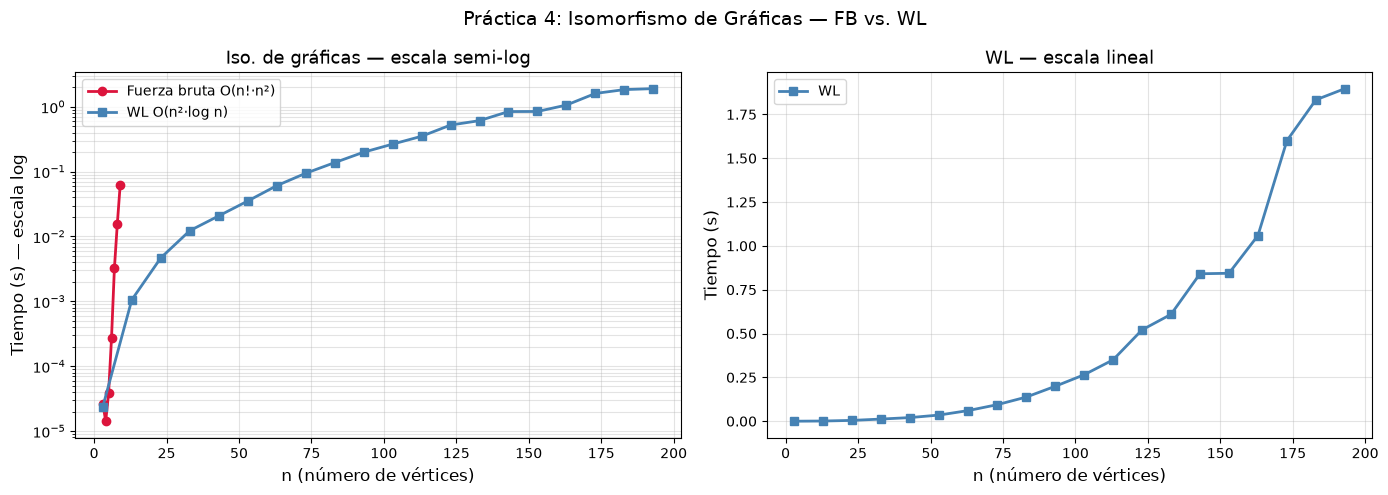

Gráfica guardada como  04_isomorfismo_tiempos.png


In [14]:
# ── Celda 7: Gráfica ─────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].semilogy(tamanos_fb, tiempos_fb, "o-", color="crimson",   lw=2, label="Fuerza bruta O(n!·n²)")
axes[0].semilogy(tamanos_wl, tiempos_wl, "s-", color="steelblue", lw=2, label="WL O(n²·log n)")
axes[0].set_xlabel("n (número de vértices)", fontsize=12)
axes[0].set_ylabel("Tiempo (s) — escala log", fontsize=12)
axes[0].set_title("Iso. de gráficas — escala semi-log", fontsize=13)
axes[0].legend(); axes[0].grid(True, which="both", alpha=0.35)

axes[1].plot(tamanos_wl, tiempos_wl, "s-", color="steelblue", lw=2, label="WL")
axes[1].set_xlabel("n (número de vértices)", fontsize=12)
axes[1].set_ylabel("Tiempo (s)", fontsize=12)
axes[1].set_title("WL — escala lineal", fontsize=13)
axes[1].legend(); axes[1].grid(True, alpha=0.35)

plt.suptitle("Práctica 4: Isomorfismo de Gráficas — FB vs. WL", fontsize=14)
plt.tight_layout()
plt.savefig("04_isomorfismo_tiempos.png", dpi=110, bbox_inches="tight")
plt.show()
print("Gráfica guardada como  04_isomorfismo_tiempos.png")

## 7. Preguntas de análisis

**Q1.** El algoritmo WL puede equivocarse: puede decir "posiblemente isomorfas"
cuando en realidad no lo son. Construye (o busca) un par de gráficas
no-isomorfas que WL no pueda distinguir.
*(Pista: busca "Shrikhande graph" o gráficas fuertemente regulares)*

**Q2.** WL es eficiente pero no correcto. La fuerza bruta es correcta pero
ineficiente. ¿Cómo combinarías ambos para tener un algoritmo práctico?

**Q3.** Babai (2015) demostró que GI puede resolverse en tiempo
$n^{O(\log^c n)}$ para alguna constante $c$. Esto es super-polinomial pero
sub-exponencial. ¿Esto implica que GI está en P? ¿Por qué?

**Q4.** Si demostraras que GI es NP-completo, ¿qué consecuencias tendría para
los sistemas de verificación de identidad basados en gráficas moleculares?

**Q5.** GI tiene muchas aplicaciones en química computacional (verificar si dos
moléculas son la misma). ¿Por qué la clase GI es particularmente interesante
para la comunidad de complejidad computacional?

Q1:
Ejemplo obtenido en <https://en.wikipedia.org/wiki/Graph_neural_network#/media/File:GNN_representational_limits.png>\
![](GNN_representational_limits.png)

Q2:
Se puede hacer un paso preliminar con WL para determinar si dos graficas definitivamente no son isomorfas, si hay una posibilidad de que dos graficas sean isomorfas, se usa fuerza bruta para verificar la respuesta de WL\
Este algoritmo es más practico que usar unicamente uno, pues disminuye los casos en los que se usa fuerza bruta sin comprometer la correctez de la respuesta

Q3:
No, pues esa complejidad temporal no es polinomial, por lo que GI no puede estar en P

Q4:
Demostrar que GI es NP-completo

Q5:
La importancia de GI recae en la posibilidad de que no sea ni NP-completo ni P, de ser cierta esta sospecha sería prueba definitiva de que P != NP